# Notebook 14 – Model Evaluation: Classification
### Sprint 7 – Machine Learning Fundamentals for AI/ML Engineers

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — same dataset as Notebooks 4–10, 12.
**Target:** 0 = malignant, 1 = benign.

## Step 1 – Understand the Concept

### Confusion Matrix
|  | Predicted Negative | Predicted Positive |
|---|---|---|
| **Actual Negative** | True Negative (TN) | False Positive (FP) |
| **Actual Positive** | False Negative (FN) | True Positive (TP) |

Malignant (0) is treated as the "positive" class of clinical interest, since missing it is the costly error.
- **TP:** correctly predicted malignant. **TN:** correctly predicted benign.
- **FP:** predicted malignant, actually benign ("false alarm").
- **FN:** predicted benign, actually malignant (**the dangerous miss**).

### Accuracy
`(TP+TN)/(TP+TN+FP+FN)` — overall fraction correct. Misleading on imbalanced data: always-predict-benign on a
63%-benign dataset scores 63% accuracy while catching zero malignant cases.

### Precision
`TP/(TP+FP)` — of everything predicted positive, how much actually was? High = few false alarms.

### Recall (Sensitivity)
`TP/(TP+FN)` — of everything actually positive, how much did we catch? High = few missed cases. **Priority
metric here.**

### Specificity
`TN/(TN+FP)` — the "recall" of the negative class.

### F1 Score
`2*(Precision*Recall)/(Precision+Recall)` — harmonic mean, single balanced number.

### ROC Curve and AUC
ROC plots True Positive Rate vs False Positive Rate across every threshold. AUC summarizes into one number: the
probability the model ranks a random positive higher than a random negative. AUC=1.0 perfect; AUC=0.5 random.

### Precision-Recall Curve
Precision vs Recall across thresholds — more informative than ROC on imbalanced data, since ROC's FPR denominator
includes the large negative class.

### Why is accuracy alone not always sufficient?
A model that never predicts malignant scores high accuracy on this ~63/37 split while having 0% recall on
malignant — clinically useless despite a "good-looking" accuracy number.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score,
                              f1_score, roc_curve, roc_auc_score, precision_recall_curve,
                              classification_report)

RANDOM_STATE = 42

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

model = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 0]  # probability of class 0 (malignant)

print("Test set shape:", X_test.shape)

Test set shape: (114, 30)


## Step 2 – Demonstrate the Concept

**Simple example:** A COVID test that's 99% accurate sounds great — but if only 1% of the population has COVID, a
test that always says "negative" is also 99% accurate while catching zero real cases. Recall is what matters.

**Business example:** A fraud detection system with high precision but low recall keeps complaints low but lets
fraud through — the acceptable trade-off depends on the cost of each error type.

**AI/ML use case:** Cancer diagnosis (this notebook) — recall on malignant prioritized since a false negative is
far more dangerous than a false positive.

## Step 3 – Implement the Concept

In [2]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
precision_m = precision_score(y_test, y_pred, pos_label=0)
recall_m = recall_score(y_test, y_pred, pos_label=0)
specificity_m = recall_score(y_test, y_pred, pos_label=1)  # recall of benign = specificity
f1_m = f1_score(y_test, y_pred, pos_label=0)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy:                 {acc:.4f}")
print(f"Precision (malignant=1):  {precision_m:.4f}")
print(f"Recall/Sensitivity (mal): {recall_m:.4f}")
print(f"Specificity (benign):     {specificity_m:.4f}")
print(f"F1 Score (malignant):     {f1_m:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["malignant(0)", "benign(1)"]))

Accuracy:                 0.9649
Precision (malignant=1):  0.9750
Recall/Sensitivity (mal): 0.9286
Specificity (benign):     0.9861
F1 Score (malignant):     0.9512

              precision    recall  f1-score   support

malignant(0)       0.97      0.93      0.95        42
   benign(1)       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



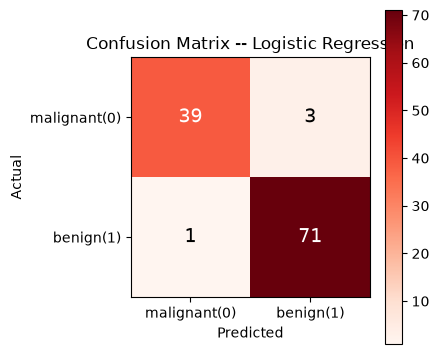

In [3]:
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Reds")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["malignant(0)", "benign(1)"])
ax.set_yticklabels(["malignant(0)", "benign(1)"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix -- Logistic Regression")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
plt.colorbar(im)
plt.tight_layout()
plt.show()

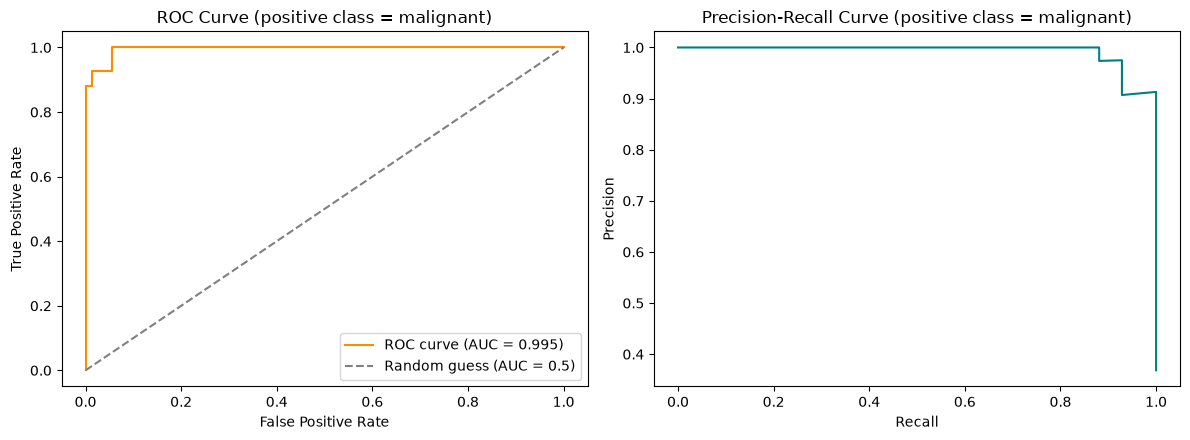

AUC: 0.9954


In [4]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba, pos_label=0)
auc = roc_auc_score((y_test == 0).astype(int), y_proba)

prec_curve, rec_curve, thresholds_pr = precision_recall_curve(y_test, y_proba, pos_label=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})", color="darkorange")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess (AUC = 0.5)")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (positive class = malignant)")
axes[0].legend()

axes[1].plot(rec_curve, prec_curve, color="teal")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (positive class = malignant)")

plt.tight_layout()
plt.show()

print(f"AUC: {auc:.4f}")

### What the code does
- `pos_label=0` explicitly set on `precision_score`/`recall_score`/`f1_score`/`roc_curve` since sklearn defaults
  to treating label `1` as positive — the wrong (less important) class here by default.
- `roc_curve` sweeps the threshold from 0 to 1, recording FPR/TPR at every threshold.
- `precision_recall_curve` does the analogous sweep for precision vs recall.

### What the output means
AUC=0.9954 means the model ranks malignant cases higher than benign cases almost every time, across all
thresholds — a threshold-independent measure of separability.

## Step 4 – Interpret the Result

**Why is accuracy alone not sufficient here?** Classes are imbalanced (~63% benign/37% malignant); an
always-predict-benign baseline scores ~63% accuracy with 0% recall on malignant — clinically useless. Accuracy
must always be read alongside recall and the confusion matrix.

**What does the confusion matrix tell us?** Exactly how many malignant cases were caught (TP), missed (FN — the
costly error), correctly cleared benign (TN), and unnecessarily flagged (FP).

**Is recall high enough?** Recall here is 0.9286 — below the ~0.90–0.95 typical bar for a screening-support tool.
Since every missed case (FN) is a real clinical risk, the next step would be adjusting the classification
threshold (trading some precision for higher recall) rather than accepting the default 0.5 cutoff.

**What does AUC add?** AUC (0.9954) evaluates ranking quality across every threshold — a high AUC with a
disappointing recall at the default threshold suggests the fix is to move the threshold, not change the model.

**What could be improved?**
- Explicitly choose a threshold guaranteeing recall ≥ 0.95 using the Precision-Recall curve, instead of the
  default 0.5 cutoff.
- Use `class_weight="balanced"` during training.
- Compare this model's ROC/AUC against Random Forest (Notebook 9) and SVM (Notebook 10) on the same test set.